In [1]:
# ! source get_paths.sh web sf_curr

In [1]:
import os
os.environ['DATASET_PATH'] = '/shared/john/model_training/'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


In [2]:
import os 
import argparse
import torch
import os
from omegaconf import OmegaConf
from tqdm import tqdm
from torchvision import transforms
from torchvision.io import write_video
from einops import rearrange
import torch.distributed as dist
from torch.utils.data import DataLoader, SequentialSampler
from torch.utils.data.distributed import DistributedSampler

from pipeline import (
    CausalDiffusionInferencePipeline,
    CausalInferencePipeline,
    ProgressiveCausalInferencePipeline
)
from utils.dataset import TextDataset, TextImagePairDataset
from utils.misc import set_seed

from demo_utils.memory import gpu, get_cuda_free_memory_gb, DynamicSwapInstaller

/shared/miniconda3/envs/self_forcing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
parser = argparse.ArgumentParser()
parser.add_argument("--config_path", type=str, help="Path to the config file")
parser.add_argument("--checkpoint_path", type=str, help="Path to the checkpoint folder")
parser.add_argument("--data_path", type=str, help="Path to the dataset")
parser.add_argument("--extended_prompt_path", type=str, help="Path to the extended prompt")
parser.add_argument("--output_folder", type=str, help="Output folder")
parser.add_argument("--num_output_frames", type=int, default=21,
                    help="Number of overlap frames between sliding windows")
parser.add_argument("--i2v", action="store_true", help="Whether to perform I2V (or T2V by default)")
parser.add_argument("--use_ema", action="store_true", help="Whether to use EMA parameters")
parser.add_argument("--seed", type=int, default=0, help="Random seed")
parser.add_argument("--num_samples", type=int, default=1, help="Number of samples to generate per prompt")
parser.add_argument("--save_with_index", action="store_true",
                    help="Whether to save the video using the index or prompt as the filename")
parser.add_argument("--first_window_size", type=int, default=7,
                    help="how many latent frames are in the first window?")

args = parser.parse_args([])

# # for own trained model using the progressive window strategy
# args.config_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/model_training/260203_view_dmd_windows/view_dmd_windows.yaml"
# args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/model_training/260203_view_dmd_windows/logs/checkpoint_model_000750/model.pt"
# args.config_path = "/shared/john/"
# args.premade_model = False



# self-forcing
args.config_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing/self_forcing_dmd.yaml"
args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing/self_forcing_dmd.pt"
args.premade_model = True
args.use_ema = True
args.first_window_size = 1


In [6]:
# misc setup
# Initialize distributed inference
if "LOCAL_RANK" in os.environ:
    dist.init_process_group(backend='nccl')
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    device = torch.device(f"cuda:{local_rank}")
    world_size = dist.get_world_size()
    set_seed(args.seed + local_rank)
else:
    device = torch.device("cuda")
    local_rank = 0
    world_size = 1
    set_seed(args.seed)
    

torch.set_grad_enabled(False)

config = OmegaConf.load(args.config_path)
default_config = OmegaConf.load("configs/default_config.yaml")
config = OmegaConf.merge(default_config, config)

In [8]:
# Model loading


# pipeline = ProgressiveCausalInferencePipeline(config,device=device, initial_first_window_size= args.first_window_size)
pipeline = CausalInferencePipeline(config, device=device)

print("type(pipeline)",type(pipeline))

if args.checkpoint_path:
    state_dict = torch.load(args.checkpoint_path, map_location="cpu")
    # Trained model has misnamed parameters
    # pipeline.generator.load_state_dict(state_dict['generator' if not args.use_ema else 'generator_ema'])
    if not args.premade_model:
        if args.use_ema:
            temporary_state_dict = {k.replace("._fsdp_wrapped_module",""):v for k,v in state_dict['generator_ema'].items()}
        else:
            temporary_state_dict = {k.replace("._fsdp_wrapped_module",""):v for k,v in state_dict['generator'].items()}
    else:
        temporary_state_dict = state_dict['generator' if not args.use_ema else 'generator_ema']
    pipeline.generator.load_state_dict(temporary_state_dict)

# pipeline = pipeline.to(dtype=torch.bfloat16)
pipeline.text_encoder.to(device=gpu)
pipeline.generator.to(device=gpu)
pipeline.vae.to(device=gpu)

pipeline = pipeline.to(device="cuda", dtype=torch.bfloat16)


using 1.3b model


KV inference with 3 frames per block
type(pipeline) <class 'pipeline.causal_inference.CausalInferencePipeline'>


In [14]:
from copy import deepcopy
# generator_copy = deepcopy(pipeline.generator)
pipeline.generator = generator_copy.to(device='cuda')

In [ ]:
pipeline.generator.model.blocks[0].forward.qkv_fn


AttributeError: 'function' object has no attribute 'qkv_fn'

: 

In [ ]:
import torch
from collections import defaultdict

class WanQKVTracer:
    def __init__(self, cpu_offload=True):
        self.cpu_offload = cpu_offload
        self.storage = defaultdict(list)
        self.handles = []
        self.current_step = 0

#     def _store(self, name, kind, tensor):
#         self.current_step += 1 
#         if tensor is None:
#             return
#         x = tensor.detach()
#         if self.cpu_offload:
#             x = x.float().cpu()
#         self.storage[name].append({
#             "step": self.current_step,
#             "kind": kind,
#             "tensor": x,
#         })

#     def _make_hook(self, name, kind):
#         def hook(module, inputs, output):
#             self._store(name, kind, output)
#         return hook

#     def attach_block(self, pipeline, block_idx=8):
#         attn = pipeline.generator.model.blocks[block_idx].self_attn
#         base_name = f"blocks.{block_idx}.self_attn"

#         print(attn)

#         self.handles.append(attn.q.register_forward_hook(self._make_hook(base_name, "q")))
#         self.handles.append(attn.k.register_forward_hook(self._make_hook(base_name, "k")))
#         self.handles.append(attn.v.register_forward_hook(self._make_hook(base_name, "v")))

#         # optional: capture final attention output too
#         self.handles.append(attn.o.register_forward_hook(self._make_hook(base_name, "o")))

#     def remove(self):
#         for h in self.handles:
#             h.remove()
#         self.handles.clear()

# def to_heads(x, num_heads):
#     # x: [B, N, C]
#     B, N, C = x.shape
#     head_dim = C // num_heads
#     return x.view(B, N, num_heads, head_dim).permute(0, 2, 1, 3)  # [B,H,N,D]

In [8]:
# attn = pipeline.generator.model.blocks[8].self_attn
# print(attn)
# print("has num_heads:", hasattr(attn, "num_heads"))
# if hasattr(attn, "num_heads"):
#     print("num_heads =", attn.num_heads)

In [9]:
# tracer = WanQKVTracer(cpu_offload=True)
# tracer.attach_block(pipeline, block_idx=8)

# For inference

In [10]:
sampled_noise = torch.randn(
            [args.num_samples, args.num_output_frames, 16, 60, 104], device=device, dtype=torch.bfloat16
        )

text_prompt = "Two people are dancing in the rain."
negative_prompt = '色调艳丽，过曝，静态，细节模糊不清，字幕，风格，作品，画作，画面，静止，整体发灰，最差质量，低质量，JPEG压缩残留，丑陋的，残缺的，多余的手指，画得不好的手部，画得不好的脸部，畸形的，毁容的，形态畸形的肢体，手指融合，静止不动的画面，杂乱的背景，三条腿，背景人很多，倒着走'

prompts = [text_prompt] * args.num_samples
negative_prompts = [negative_prompt] * args.num_samples


In [11]:
# [pipeline.kv_cache1[i]['k']*10 for i in range(len(pipeline.kv_cache1))]



In [12]:
# video, latents = pipeline.inference_retain_flow(
#             noise=sampled_noise,
#             text_prompts=prompts,
#             return_latents=True
#         )

video, latents = pipeline.inference_chunk_prior_copied_over(
            noise=sampled_noise,
            text_prompts=prompts,
            return_latents=True
        )


current_timestep: 1000.0
True
current_timestep: 960.0
False
current_timestep: 888.888916015625
False
current_timestep: 727.2727661132812
False
denoised_pred.flatten(0, 1).shape torch.Size([3, 16, 60, 104])
noisy_input[:, current_start_frame:current_start_frame + current_num_frames].flatten(0, 1).shape torch.Size([0, 16, 60, 104])
current_timestep: 1000.0
True
current_timestep: 960.0
False
current_timestep: 888.888916015625
False
current_timestep: 727.2727661132812
False
denoised_pred.flatten(0, 1).shape torch.Size([3, 16, 60, 104])
noisy_input[:, current_start_frame:current_start_frame + current_num_frames].flatten(0, 1).shape torch.Size([0, 16, 60, 104])
current_timestep: 1000.0
True
current_timestep: 960.0
False
current_timestep: 888.888916015625
False
current_timestep: 727.2727661132812
False
denoised_pred.flatten(0, 1).shape torch.Size([3, 16, 60, 104])
noisy_input[:, current_start_frame:current_start_frame + current_num_frames].flatten(0, 1).shape torch.Size([0, 16, 60, 104])
curr

In [19]:
import torch

def fft_low_high_pass(latent, cutoff_ratio=0.15):
    """
    latent: tensor of shape [..., H, W]
    cutoff_ratio: fraction of image radius to keep as low frequency

    Returns:
        low_feat: low-pass filtered reconstruction
        high_feat: high-pass filtered reconstruction
        fft_shifted: shifted FFT
        low_mask: low-frequency mask
        high_mask: high-frequency mask
    """

    if latent.dtype == torch.bfloat16:
        latent = latent.float()  # FFT doesn't support bfloat16, so convert to float32 for computation
        
    # FFT over spatial dimensions
    fft = torch.fft.fft2(latent, dim=(-2, -1))
    fft_shifted = torch.fft.fftshift(fft, dim=(-2, -1))

    H, W = latent.shape[-2], latent.shape[-1]
    cy, cx = H // 2, W // 2

    y = torch.arange(H, device=latent.device).float() - cy
    x = torch.arange(W, device=latent.device).float() - cx
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    rr = torch.sqrt(xx**2 + yy**2)

    max_r = min(H, W) / 2.0
    cutoff = cutoff_ratio * max_r

    low_mask_2d = (rr <= cutoff).to(latent.dtype)
    high_mask_2d = 1.0 - low_mask_2d

    # Expand mask to latent shape
    while low_mask_2d.ndim < latent.ndim:
        low_mask_2d = low_mask_2d.unsqueeze(0)
        high_mask_2d = high_mask_2d.unsqueeze(0)

    low_fft = fft_shifted * low_mask_2d
    high_fft = fft_shifted * high_mask_2d

    # Inverse shift + inverse FFT
    low_ifft = torch.fft.ifftshift(low_fft, dim=(-2, -1))
    high_ifft = torch.fft.ifftshift(high_fft, dim=(-2, -1))

    low_feat = torch.fft.ifft2(low_ifft, dim=(-2, -1)).real
    high_feat = torch.fft.ifft2(high_ifft, dim=(-2, -1)).real

    return low_feat, high_feat, fft_shifted, low_mask_2d, high_mask_2d

In [20]:
# latent = torch.randn(1, 21, 16, 60, 104).cuda()  # [B, T, C, H, W]
low, high, fft_shifted, low_mask, high_mask = fft_low_high_pass(latents, cutoff_ratio=0.2)

print(low.shape, high.shape)

torch.Size([1, 21, 16, 60, 104]) torch.Size([1, 21, 16, 60, 104])


In [21]:
def convert_latent_to_video(latent):
    latent = latent.to(dtype=torch.bfloat16)
    video = pipeline.vae.decode_to_pixel(latent)

    video = (video * 0.5 + 0.5).clamp(0, 1)
    video = 255.0 * video

    return video

low_pass_video = convert_latent_to_video(low)
high_pass_video = convert_latent_to_video(high)

vid_from_latent = convert_latent_to_video(latents)



In [31]:
# import os 
# import cv2
# from IPython.display import Image, display, clear_output
# import time
# import torch

# def view_video_numpy(video, prompt):
#     """
#     video should be in the shape of (B, T, C, H, W)"""
#     fps = 1/16 #16fps

#     video = video.reshape(video.shape[0], video.shape[1], video.shape[3], video.shape[4], video.shape[2]) # [b,T,H,W,C]
#     video_frame_list = video[0].cpu().numpy()
#     # print(video_frame_list.shape)
    
#     print(video_frame_list.shape)
#     for video_frame in video_frame_list:
#         clear_output(wait=True)
#         rgb_frame = cv2.cvtColor(video_frame,cv2.COLOR_BGR2RGB)
#         # rgb_frame = video_frame
#         _, encoded_image = cv2.imencode('.jpeg',rgb_frame)
#         display(Image(data=encoded_image.tobytes()))
#         # print(prompt)
#         time.sleep(fps)


# # low_pass_video = torch.load("progressive_low_pass_video.mp4")
# # high_pass_video = torch.load("progressive_high_pass_video.mp4")
# view_video_numpy(low_pass_video, "text")
# # view_video_numpy(high_pass_video, "text")

torch.save(low_pass_video,"progressive_chunk_pass_low_pass_video.mp4")
torch.save(high_pass_video,"progressive_chunk_pass_high_pass_video.mp4")
# # view_video_numpy(vid_from_latent, "text")


# # torch.save(low_pass_video,"self_forcing_low_pass_video.mp4")
# # torch.save(high_pass_video,"self_forcing_high_pass_video.mp4")
# # break

# # view_video_numpy(torch.load("progressive_low_pass_video.mp4"), "text")
# # view_video_numpy(torch.load("progressive_high_pass_video.mp4"), "text")

# # view_video_numpy(torch.load("self_forcing_low_pass_video.mp4"), "text")
# # view_video_numpy(torch.load("self_forcing_high_pass_video.mp4"), "text")


In [17]:
low_pass_video.shape

torch.Size([1, 81, 3, 480, 832])

In [18]:
# pipeline.flow_pred = [ [latent @ denoising steps] * chunks]
# pipeline.flow_pred[0][3].shape 


## mean 
for chunk in pipeline.flow_pred:
    for step in chunk:
        print(step.norm())
    print("new chunk")



## torch.nn.functional.cosine_similarity
# num_denoising_steps = 4

# for step in range(num_denoising_steps):
#     prev_chunk=0
#     for curr_chunk in range(1, len(pipeline.flow_pred)):
#         # print(step.norm())

#         curr = pipeline.flow_pred[curr_chunk][step].reshape(1, -1)
#         prev = pipeline.flow_pred[prev_chunk][step].reshape(1, -1)

#         cos_sim = torch.nn.functional.cosine_similarity(curr, prev)
#         prev_chunk = curr_chunk
#         # print("cos_sim", torch.mean(cos_sim))
#         print(cos_sim)


#     print("new chunk")





AttributeError: 'CausalInferencePipeline' object has no attribute 'flow_pred'

In [ ]:
print('hi')
break

hi


SyntaxError: 'break' outside loop (1663934839.py, line 2)

In [ ]:
# tracer.storage['blocks.8.self_attn'][2]['tensor'].shape
data = tracer.storage['blocks.8.self_attn'][136]#['tensor']
data = data['tensor']

# to_heads(data, 12).shape # [1, 12, 4680, 128] = [batch, heads, tokens*3latents, 128 dimensions per head]
# 4 components *7 chunks *5 calls
# 16*2*4 # 16 channels, 2 chunks, 4 latent frames

# 4680 - 16*60*104

# 4 x 4 + 


NameError: name 'tracer' is not defined

In [ ]:
latents.shape

torch.Size([1, 21, 16, 60, 104])

In [ ]:
# View PCA for a real video
# download a real video just for comparision with PCA
# ! pip install yt-dlp
# ! yt-dlp https://youtu.be/ovD0svSrfdE -f "bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best"

import torchvision.io


video_path = "Drifting Honda City... [ovD0svSrfdE].mp4"
frames, audio, info = torchvision.io.read_video(filename=video_path, pts_unit="sec")


/shared/miniconda3/envs/self_forcing/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


In [ ]:
frames, audio, info = torchvision.io.read_video(filename=video_path, pts_unit="sec")

frames.shape #torch.Size([378, 360, 640, 3])
frames = torch.nn.functional.interpolate(frames.permute(0, 3, 1, 2), size=(480, 832), mode='bilinear').permute(0, 2, 3, 1)  # [num_frames, height, width, channels]
frames = frames.unsqueeze(0).permute(0,4,1,2,3)[:,:, -81:, ...].to(dtype=torch.bfloat16, device="cuda")  # [1, 3, num_frames, height, width]
frames.shape


video_frames = pipeline.vae.encode_to_latent(frames)[0].unsqueeze(0) # [1, 21, 16, 60, 104]
latents = video_frames
print(latents.shape)

/shared/miniconda3/envs/self_forcing/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


torch.Size([1, 21, 16, 60, 104])


In [ ]:
import torch

# Example tensor
# x = torch.randn(1, 21, 16, 60, 104)
x = latents.float()

# Remove batch dim, permute to [frames, height, width, channels] and flatten
x_flat = x[0].permute(1, 2, 3, 0).reshape(-1, 21)  # [num_samples, num_features]
print(x_flat.shape)
# torch.Size([16*60*104, 21])


# k = number of PCA components you want
k = 1

U, S, V = torch.pca_lowrank(x_flat, q=k)  # U:[num_samples,k], S:[k], V:[num_features,k]

x_centered = x_flat - x_flat.mean(dim=0, keepdim=True)
x_pca = x_centered @ V  # shape: [num_samples, k]

frames, height, width = 16, 60, 104
x_pca_reshaped = x_pca.reshape(frames, height, width, k)  # [16, 60, 104, k]

torch.Size([99840, 21])


In [ ]:
frame_similarity = torch.matmul(V, V.T)  # [frames, frames]
frame_similarity /= torch.norm(V, dim=1, keepdim=True)
frame_similarity /= torch.norm(V, dim=1, keepdim=True).T


frame_similarity

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000],
        [1.0000, 1.0

In [ ]:
V

tensor([[-0.1484],
        [-0.1999],
        [-0.2177],
        [-0.2215],
        [-0.2199],
        [-0.2181],
        [-0.2171],
        [-0.2172],
        [-0.2186],
        [-0.2194],
        [-0.2196],
        [-0.2207],
        [-0.2229],
        [-0.2252],
        [-0.2268],
        [-0.2278],
        [-0.2278],
        [-0.2271],
        [-0.2257],
        [-0.2244],
        [-0.2237]], device='cuda:0')

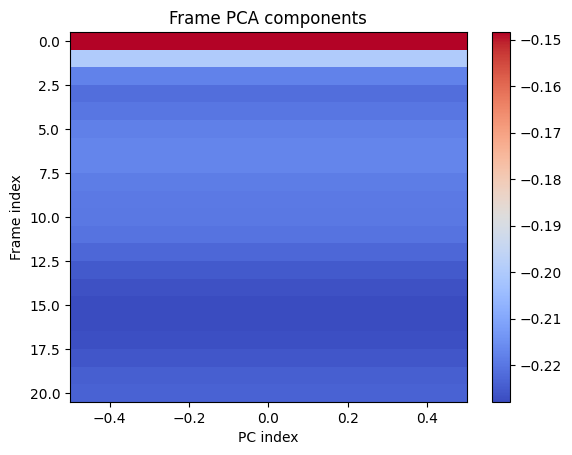

In [ ]:
import matplotlib.pyplot as plt

# V: [frames, k]  # each row = frame, each column = PC
plt.imshow(V.cpu(), aspect='auto', cmap='coolwarm')
plt.colorbar()
plt.xlabel('PC index')
plt.ylabel('Frame index')
plt.title('Frame PCA components')
plt.show()

In [ ]:
# VIEW THE QK 
import torch

# Example tensor
# x = torch.randn(1, 21, 16, 60, 104)
x = data.float()

# Remove batch dim, permute to [frames, height, width, channels] and flatten
x_flat = x[0].permute(1, 2, 3, 0).reshape(-1, 16)  # [num_samples, num_features]
print(x_flat.shape)
# torch.Size([16*60*104, 21])


# k = number of PCA components you want
k = 1

U, S, V = torch.pca_lowrank(x_flat, q=k)  # U:[num_samples,k], S:[k], V:[num_features,k]

x_centered = x_flat - x_flat.mean(dim=0, keepdim=True)
x_pca = x_centered @ V  # shape: [num_samples, k]

frames, height, width = 21, 60, 104
x_pca_reshaped = x_pca.reshape(frames, height, width, k)  # [16, 60, 104, k]

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 2 is not equal to len(dims) = 4

In [ ]:
V.shape

torch.Size([16, 1])

In [ ]:
x_pca_reshaped.shape

torch.Size([21, 60, 104, 1])

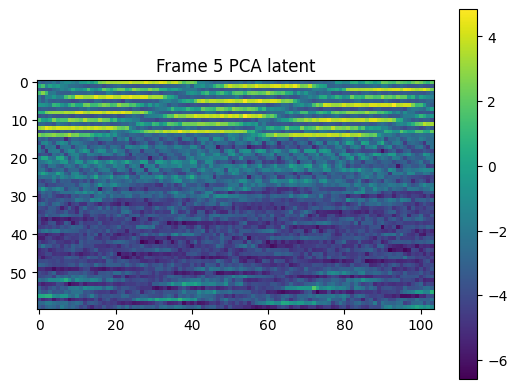

In [ ]:
import matplotlib.pyplot as plt

print_latent = x_pca_reshaped.cpu()  # [21, 60, 104, 1]
print_latent = print_latent.squeeze(-1)  # [21, 60, 104]


frame_idx = 5
plt.imshow(print_latent[frame_idx], cmap='viridis')
plt.colorbar()
plt.title(f'Frame {frame_idx} PCA latent')
plt.show()